Project Question - Which audio features can tell us most about how popular a song will be?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub 
import os

In [2]:
path = kagglehub.dataset_download("joebeachcapital/30000-spotify-songs")
csv_path = os.path.join(path, "spotify_songs.csv")
df = pd.read_csv(csv_path)
print(df.head())

                 track_id                                         track_name  \
0  6f807x0ima9a1j3VPbc7VN  I Don't Care (with Justin Bieber) - Loud Luxur...   
1  0r7CVbZTWZgbTCYdfa2P31                    Memories - Dillon Francis Remix   
2  1z1Hg7Vb0AhHDiEmnDE79l                    All the Time - Don Diablo Remix   
3  75FpbthrwQmzHlBJLuGdC7                  Call You Mine - Keanu Silva Remix   
4  1e8PAfcKUYoKkxPhrHqw4x            Someone You Loved - Future Humans Remix   

       track_artist  track_popularity          track_album_id  \
0        Ed Sheeran                66  2oCs0DGTsRO98Gh5ZSl2Cx   
1          Maroon 5                67  63rPSO264uRjW1X5E6cWv6   
2      Zara Larsson                70  1HoSmj2eLcsrR0vE9gThr4   
3  The Chainsmokers                60  1nqYsOef1yKKuGOVchbsk6   
4     Lewis Capaldi                69  7m7vv9wlQ4i0LFuJiE2zsQ   

                                    track_album_name track_album_release_date  \
0  I Don't Care (with Justin Bieber) [Loud Luxu

## Handle Duplicates and Missing Values

In [3]:
df_clean = df.drop_duplicates(subset=['track_name', 'track_artist'], keep='first')
df_clean = df_clean.dropna()

In [4]:
cols_to_drop = ['track_album_id', 'track_album_name', 
                'track_album_release_date', 'playlist_name', 'playlist_id']
df_clean = df_clean.drop(columns=cols_to_drop)

In [5]:
print(f"Cleaned Shape: {df_clean.shape}")

Cleaned Shape: (26229, 18)


## Visualizing our data
Let's take a look at the distribution of popularity amongst the tracks.

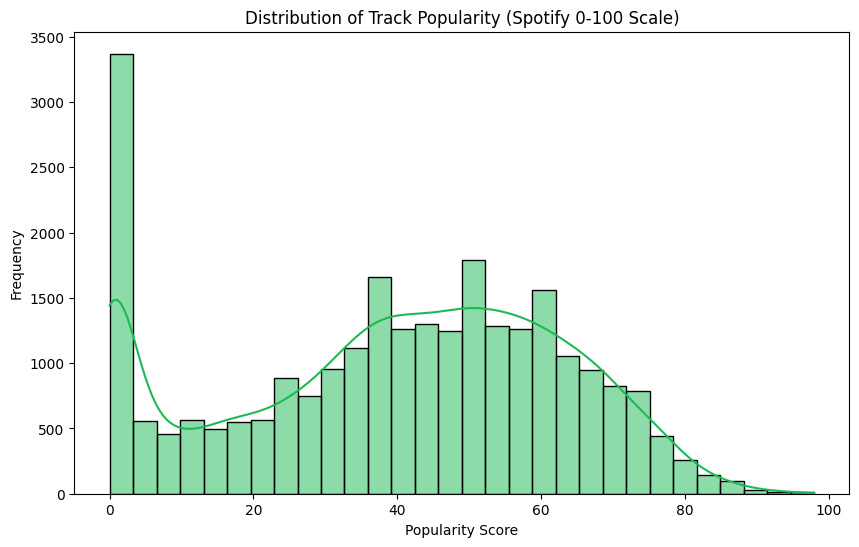

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['track_popularity'], bins=30, color='#1DB954', kde=True)
plt.title('Distribution of Track Popularity (Spotify 0-100 Scale)')
plt.xlabel('Popularity Score')
plt.ylabel('Frequency')
plt.show()

A peak around 0, and then follows a standard normal distribution with a mean of around 50.

The data is clearly skewed. We could consider dropping all songs with extremely low popularities to normalize the data.

## Dropping data
Let's drop data will popularity < 10.

Dropped 4,383 tracks with popularity < 10.
New dataset size: 21,846 tracks.


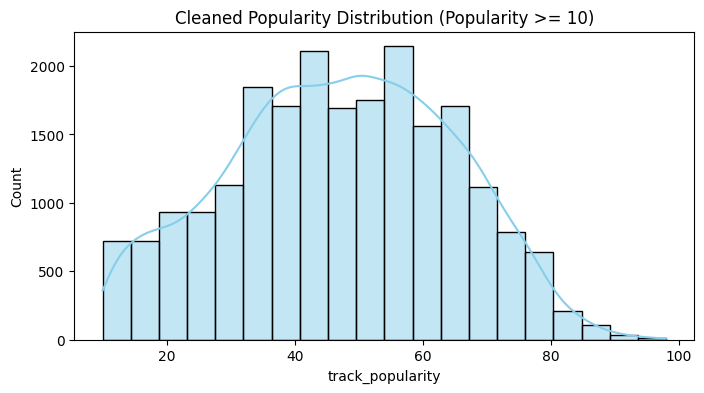

In [7]:
initial_count = len(df_clean)
df_clean = df_clean[df_clean['track_popularity'] >= 10]

dropped_count = initial_count - len(df_clean)
print(f"Dropped {dropped_count:,} tracks with popularity < 10.")
print(f"New dataset size: {len(df_clean):,} tracks.")

plt.figure(figsize=(8, 4))
sns.histplot(df_clean['track_popularity'], bins=20, kde=True, color='skyblue')
plt.title('Cleaned Popularity Distribution (Popularity >= 10)')
plt.show()

## Correlation Matrix
Let's create a correlation matrix between audio-related features to see which ones are most related to each other.

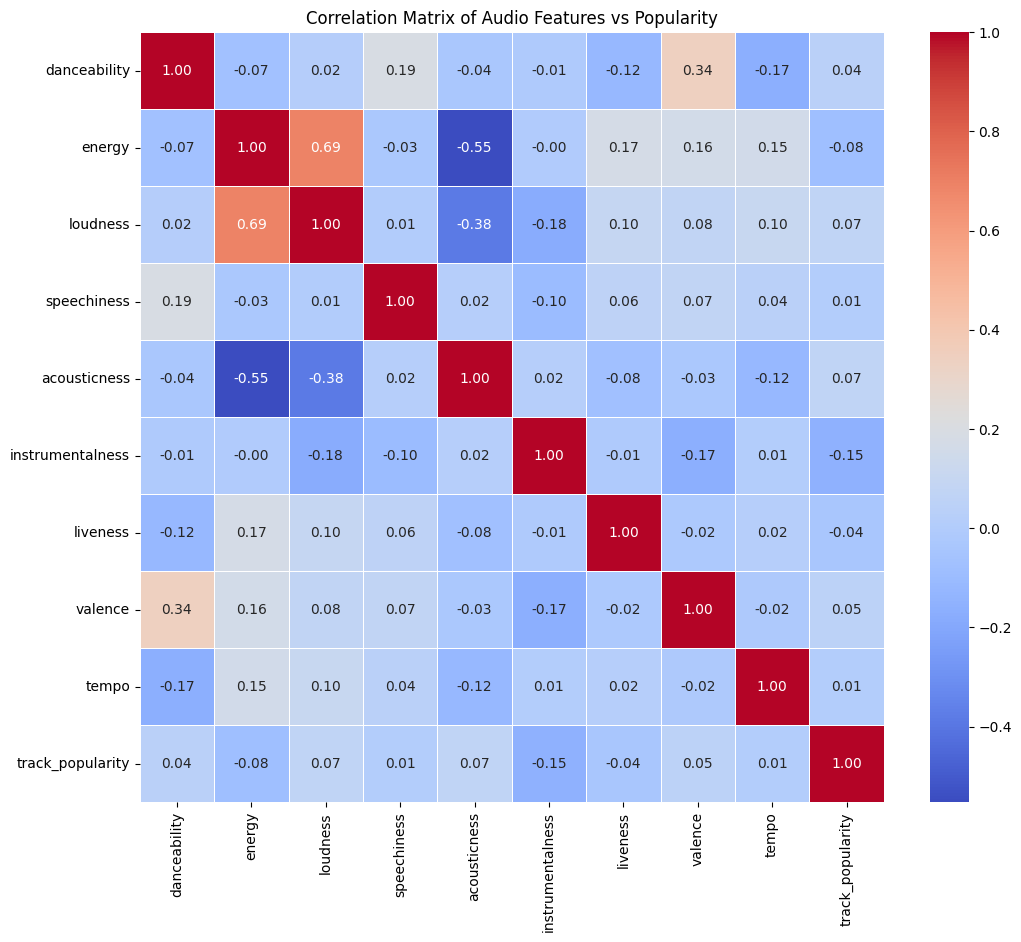

In [8]:
audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 
                  'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
corr_matrix = df_clean[audio_features + ['track_popularity']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Audio Features vs Popularity')
plt.show()

We see:
- a strong positive correlation between energy and loudness(0.69)
- a weak positive correlation between valence and danceability(0.34)
- a strong negative correlation between acousticness and energy(-0.55)
- a weak negative correlation between acousticness and loudness(-0.38)

## Acoustic features by Genre
Let's creeate boxplots of energy and danceability separated by genre to see if we can see any patterns in the data.

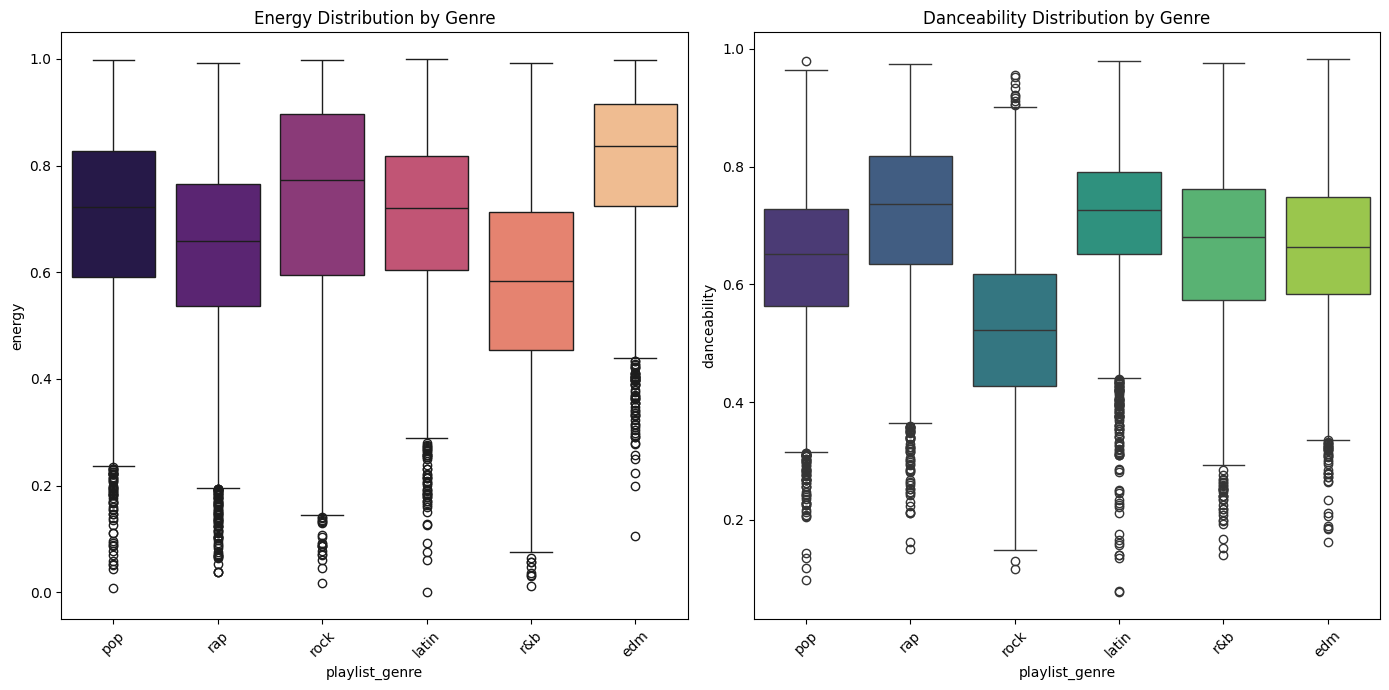

In [9]:
plt.figure(figsize=(14, 7))

#Energy vs Genre
plt.subplot(1, 2, 1)
sns.boxplot(x='playlist_genre', y='energy', data=df_clean, palette='magma', hue="playlist_genre", legend=False)
plt.title('Energy Distribution by Genre')
plt.xticks(rotation=45)

#Danceability vs Genre
plt.subplot(1, 2, 2)
sns.boxplot(x='playlist_genre', y='danceability', data=df_clean, palette='viridis', hue="playlist_genre", legend=False)
plt.title('Danceability Distribution by Genre')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

We see that r&b music has slightly less energy than the others, while edm has slightly more energy. 
For danceability, we observe that rock has significantly less danceability than the other genres.

We can see that genres can have a clear relationships on acoustic features, so we could use one-hot encoding to let the genre influence our model's predictions.

## Relationship between features
Let's take a closer look at the relationship between our most correlated features using scatter plots.

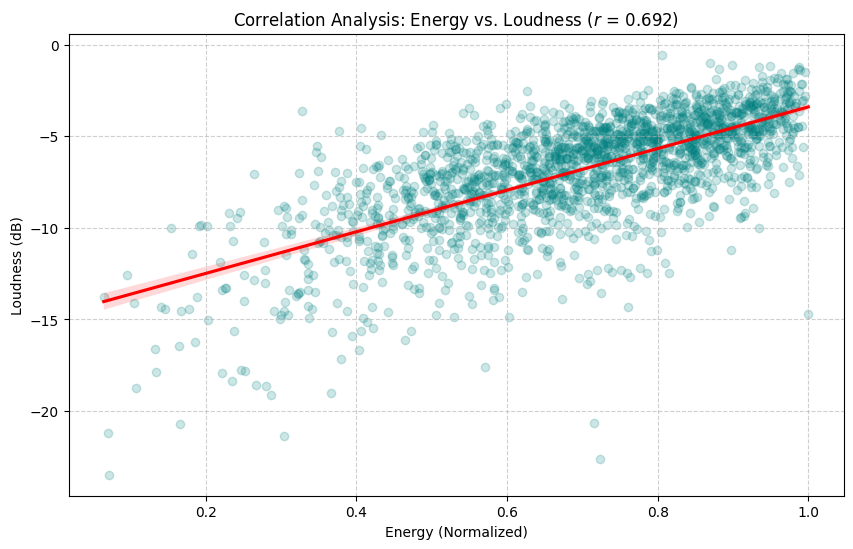

In [10]:
plt.figure(figsize=(10, 6))
sns.regplot(x='energy', y='loudness', data=df_clean.sample(2000), 
            scatter_kws={'alpha':0.2, 'color':'teal'}, 
            line_kws={'color':'red'})

r_value = df_clean['energy'].corr(df_clean['loudness'])

plt.title(f'Correlation Analysis: Energy vs. Loudness ($r$ = {r_value:.3f})')
plt.xlabel('Energy (Normalized)')
plt.ylabel('Loudness (dB)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

For our 2 strongest positively correlated variables, the scatter plot confirms a clear relationship between energy and loudness.

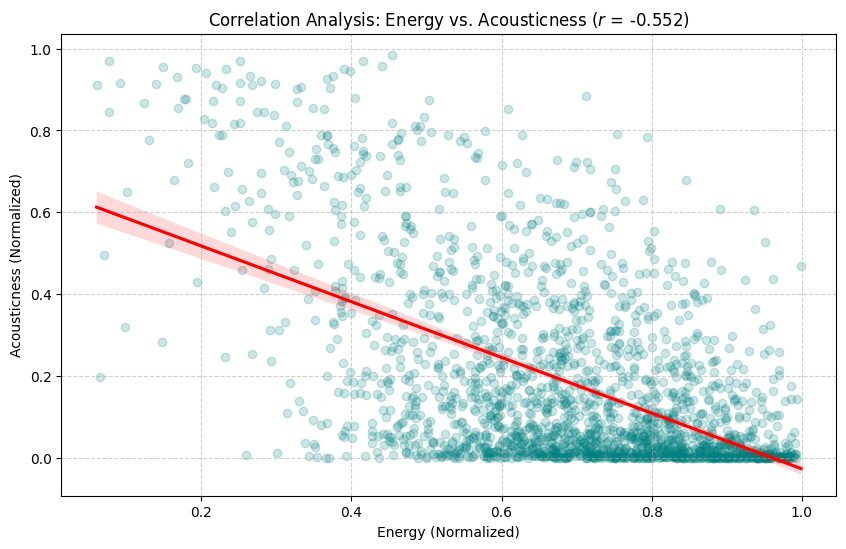

In [11]:
plt.figure(figsize=(10, 6))
sns.regplot(x='energy', y='acousticness', data=df_clean.sample(2000), 
            scatter_kws={'alpha':0.2, 'color':'teal'}, 
            line_kws={'color':'red'})

r_value = df_clean['energy'].corr(df_clean['acousticness'])

plt.title(f'Correlation Analysis: Energy vs. Acousticness ($r$ = {r_value:.3f})')
plt.xlabel('Energy (Normalized)')
plt.ylabel('Acousticness (Normalized)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

For our 2 strongest negative corrleations, the scatter plot shows a negative but less direct relationship. However, the general pattern of a song's acousticness decreasing as it's energy increases is clear.

## Correlation between audio features and popularity
Let's take a look at the correlation between the audio features and a track's popularity.

In [12]:
pop_corr = df_clean[audio_features + ['track_popularity']].corr()['track_popularity'].sort_values(ascending=False)

print("Correlation with Track Popularity:")
display(pop_corr.to_frame())

Correlation with Track Popularity:


,track_popularity
track_popularity,1.000000
acousticness,0.070435
loudness,0.068003
valence,0.050813
danceability,0.037433
tempo,0.010227
speechiness,0.008633
liveness,-0.042198
energy,-0.084678
instrumentalness,-0.154056


We see that there is no individual feature with a high correlation with popularity.

This suggests that there may be a complex relationship between multiple features, and that we could use a multiple linear regression model.